In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the Excel file into a DataFrame
excel_file_path = "bankruptcy-prevention.xlsx"
df_excel = pd.read_excel(excel_file_path)

# Define the output CSV file path
csv_file_path = "bankruptcy-prevention.csv"

# Save the DataFrame to a CSV file
df_excel.to_csv(csv_file_path, index=False)

print(f"Successfully converted '{excel_file_path}' to '{csv_file_path}'")

Successfully converted 'bankruptcy-prevention.xlsx' to 'bankruptcy-prevention.csv'


In [5]:
df = pd.read_csv("bankruptcy-prevention.csv", sep = ';', header = 0)
df.columns = df.columns.str.strip()
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [7]:
df.shape

(250, 7)

In [8]:
df.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy


In [10]:
df.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

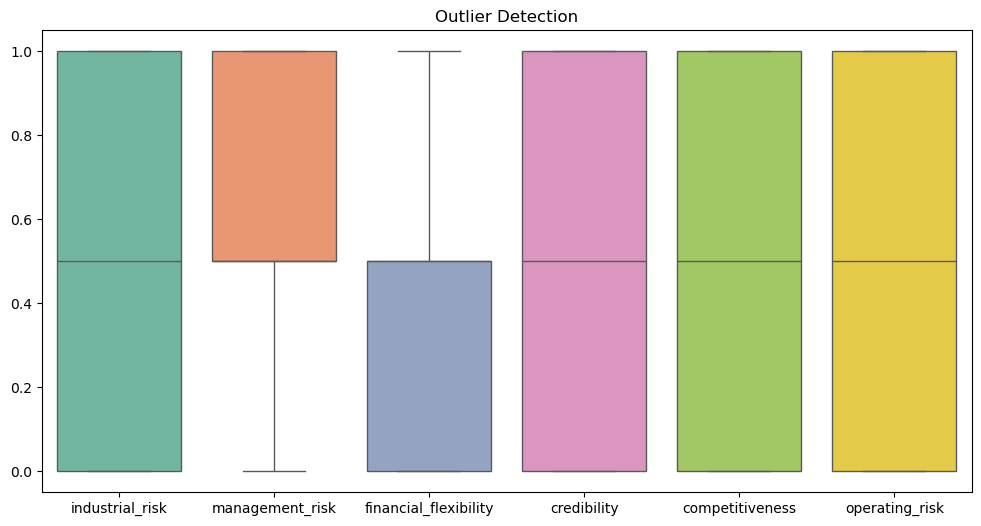

In [11]:
# Checking Outlier
plt.figure(figsize=(12,6))
sns.boxplot(data=df, palette='Set2')
plt.title("Outlier Detection")
plt.show()

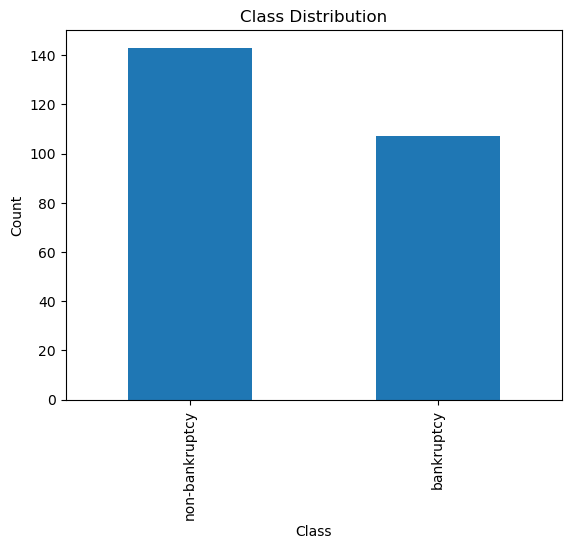

In [12]:
# Class distribution
plt.figure()
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

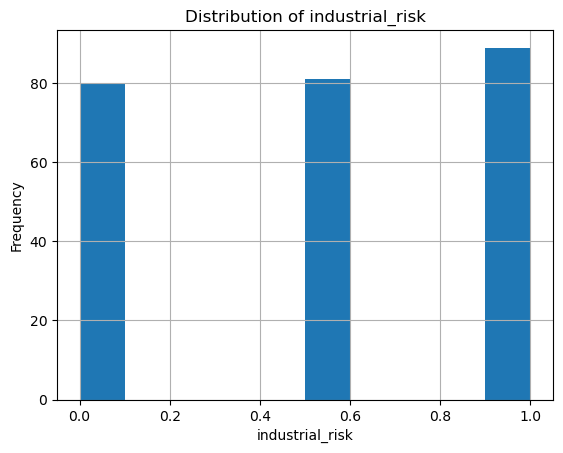

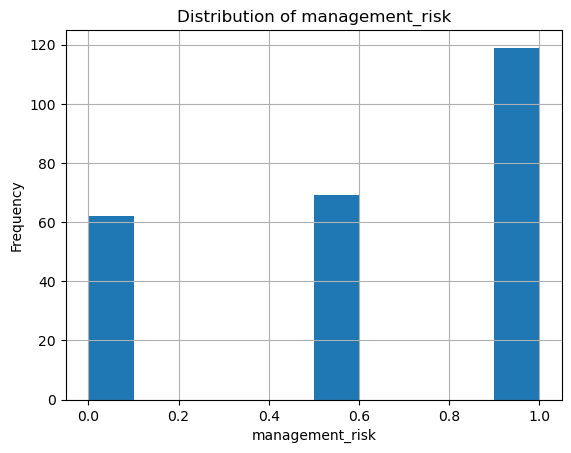

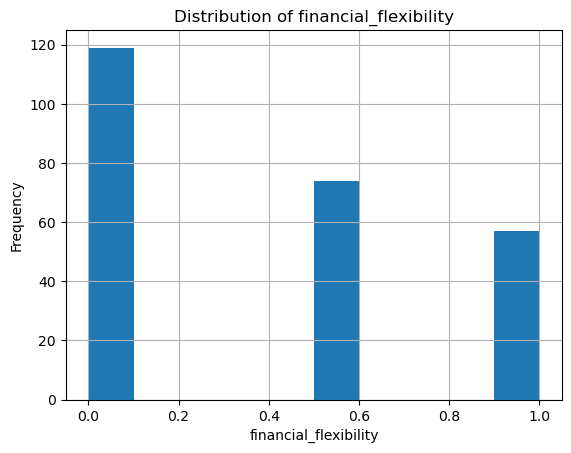

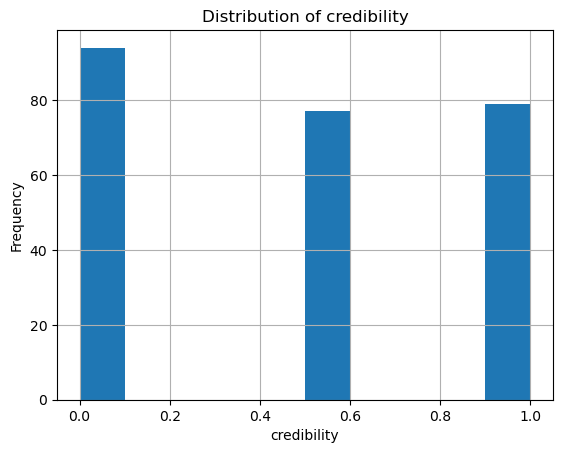

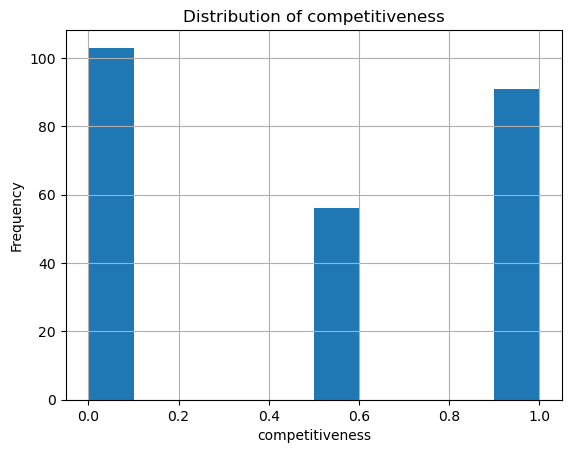

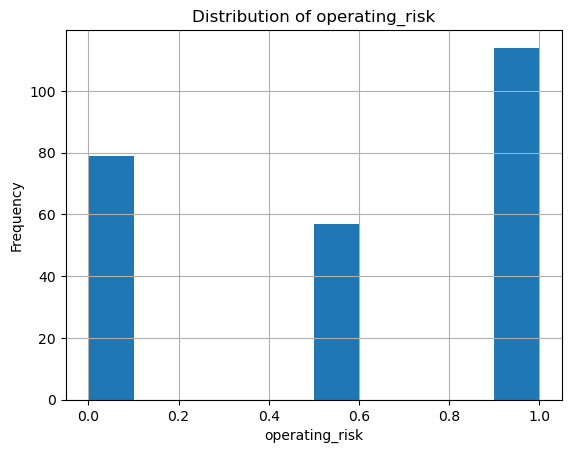

In [13]:
# Feature distributions (histograms)
for col in df.columns[:-1]:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


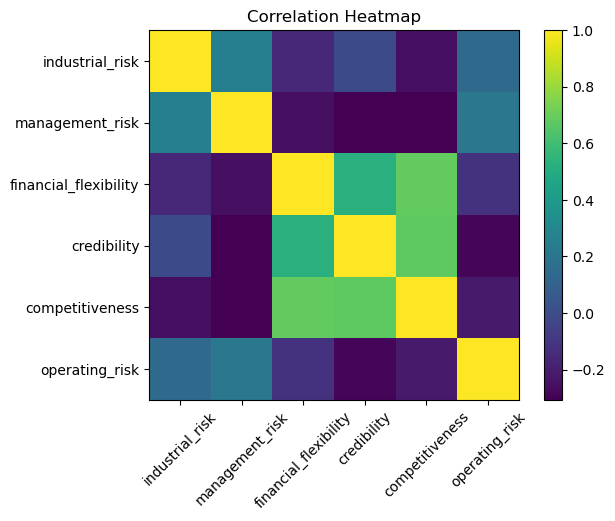

In [14]:
# Correlation heatmap (no color specified, default used)
plt.figure()
corr = df.drop('class', axis=1).corr()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

In [15]:
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy


## Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [17]:
df['class']=le.fit_transform(df['class'])

In [18]:
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0
2,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.5,0.0,0.0,0.5,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0


In [19]:
df['class'].unique()

array([0, 1])

### Feature scaling is not required because the dataset contains ordinal categorical features already encoded in a normalized range.

In [20]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(",", "")
df.columns = df.columns.str.lower()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [22]:
X = df.drop("class", axis=1)
y = df["class"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model 1 , 2 : LOGISTIC REGRESSION & RANDOM FOREST**

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [25]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

LR Accuracy: 1.0
RF Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [26]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_rf))

[[21  0]
 [ 1 28]]


In [27]:
print(df.columns)

Index(['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk', 'class'],
      dtype='object')


In [28]:
print(df['class'].unique())

[0 1]


In [29]:
print(type(lr))
print(type(rf))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [30]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

LR Accuracy: 1.0
RF Accuracy: 0.98


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Performance:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Performance:
Accuracy : 0.98
Precision: 1.0
Recall   : 0.9655172413793104
F1 Score : 0.9824561403508771


**Model 3 : Support Vector Machine (SVM)**

In [35]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_svm = svm_model.predict(X_test)

print("SVM Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM Performance:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [37]:
from sklearn.metrics import classification_report

y_pred_svm = svm_model.predict(X_test)

print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



**Model 4 : Gradient Boosting**

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [39]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

Gradient Boosting Performance:
Accuracy : 0.98
Precision: 1.0
Recall   : 0.9655172413793104
F1 Score : 0.9824561403508771


In [40]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



**MODEL EVALUATION**

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression      1.00        1.0  1.000000  1.000000
1        Random Forest      0.98        1.0  0.965517  0.982456
2                  SVM      1.00        1.0  1.000000  1.000000
3    Gradient Boosting      0.98        1.0  0.965517  0.982456


**CROSS VALIDATION**

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gb_model, X, y, cv=5)
print(scores.mean())

0.9800000000000001


In [43]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(rf, X, y, cv=5)
print(rf_scores.mean())

0.9960000000000001


In [44]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(lr, X, y, cv=5)

print("Logistic Regression CV Score:", lr_scores.mean())

Logistic Regression CV Score: 0.9960000000000001


In [45]:
svm_scores = cross_val_score(svm_model, X, y, cv=5)

print("SVM CV Score:", svm_scores.mean())

SVM CV Score: 0.9960000000000001


In [46]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 1.0
Test Accuracy : 0.98


In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[21  0]
 [ 1 28]]


In [48]:
import pickle

# Save the trained Random Forest model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully!")

Model saved successfully!


In [50]:
pickle.dump(le, open("label_encoder.pkl", "wb"))